In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

result_path = r"C:\Users\30126\Desktop\吴鑫星兰州大学\项目\西湖大学 积分视场光谱观测\NGC1510_datacube.result"

print("文件是否存在：", os.path.exists(result_path))
print("文件路径：", result_path)

with open(result_path, 'rb') as f:
    data_dic = pickle.load(f)

print("读取成功")
print(type(data_dic))
print(data_dic.keys())

文件是否存在： True
文件路径： C:\Users\30126\Desktop\吴鑫星兰州大学\项目\西湖大学 积分视场光谱观测\NGC1510_datacube.result
读取成功
<class 'dict'>
dict_keys(['objname', 'reference_redshift', 'header', 'RA', 'DEC', 'full_wave', 'full_spec', 'full_spec_var', 'wave_fit', 'spec_fit', 'spec_var_fit', 'spec_norm', 'spec_snr', 'ppxf_fit', 'ppxf_gas_fit', 'contim_spec', 'emit_spec', 'ppxf_gas_vel', 'ppxf_gas_disp', 'ppxf_star_vel', 'ppxf_star_disp', 'ppxf_gasflux', 'Extinction'])


result_path = r"C:\Users\30126\Desktop\吴鑫星兰州大学\项目\西湖大学 积分视场光谱观测\NGC1510_datacube.result"

with open(result_path, 'rb') as f:
    data_dic = pickle.load(f)

In [3]:
data_dic.keys()

dict_keys(['objname', 'reference_redshift', 'header', 'RA', 'DEC', 'full_wave', 'full_spec', 'full_spec_var', 'wave_fit', 'spec_fit', 'spec_var_fit', 'spec_norm', 'spec_snr', 'ppxf_fit', 'ppxf_gas_fit', 'contim_spec', 'emit_spec', 'ppxf_gas_vel', 'ppxf_gas_disp', 'ppxf_star_vel', 'ppxf_star_disp', 'ppxf_gasflux', 'Extinction'])

In [4]:
gasflux_dic = data_dic['ppxf_gasflux']
gasflux_dic.keys()

dict_keys(['info', np.str_('[OII]3726'), np.str_('[OII]3729'), np.str_('Htheta'), np.str_('Heta'), np.str_('[NeIII]3869'), np.str_('Hzeta'), np.str_('[NeIII]3968'), np.str_('Heps'), np.str_('[SII]4069'), np.str_('[SII]4076'), np.str_('Hdelta'), np.str_('Hgamma'), np.str_('[OIII]4363'), np.str_('HeI4471'), np.str_('[FeIII]4658'), np.str_('HeII4686'), np.str_('Hbeta'), np.str_('[OIII]4959'), np.str_('[OIII]5007'), np.str_('HeI5875'), np.str_('[OI]6300'), np.str_('[SIII]6312'), np.str_('[OI]6364'), np.str_('[FeX]6374'), np.str_('[NII]6548'), np.str_('Halpha'), np.str_('[NII]6583'), np.str_('HeI6678'), np.str_('[SII]6716'), np.str_('[SII]6731'), np.str_('HeI7065'), np.str_('[ArIII]7136'), '[NII]5755', '[OII]7320', '[OII]7330'])

In [5]:
gasflux_dic['info']

{'line_names': array(['[OII]3726', '[OII]3729', 'Htheta', 'Heta', '[NeIII]3869', 'Hzeta',
        '[NeIII]3968', 'Heps', '[SII]4069', '[SII]4076', 'Hdelta',
        'Hgamma', '[OIII]4363', 'HeI4471', '[FeIII]4658', 'HeII4686',
        'Hbeta', '[OIII]4959', '[OIII]5007', '[NII]5755', 'HeI5875',
        '[OI]6300', '[SIII]6312', '[OI]6364', '[FeX]6374', '[NII]6548',
        'Halpha', '[NII]6583', 'HeI6678', '[SII]6716', '[SII]6731',
        'HeI7065', '[ArIII]7136', '[OII]7320', '[OII]7330'], dtype='<U11'),
 'lines': array([3726.03, 3728.82, 3797.9 , 3835.39, 3869.06, 3889.05, 3967.79,
        3970.07, 4068.6 , 4076.35, 4101.76, 4340.47, 4363.21, 4471.48,
        4658.05, 4685.7 , 4861.33, 4958.92, 5006.84, 5754.59, 5875.67,
        6300.3 , 6312.1 , 6363.67, 6374.51, 6548.03, 6562.8 , 6583.41,
        6678.  , 6716.47, 6730.85, 7065.1 , 7135.8 , 7319.99, 7330.73])}

In [6]:
gasflux_dic['Halpha'].keys()

dict_keys(['line', 'flux_snr', 'flux', 'flux_err'])

In [7]:
Ha_flux = gasflux_dic['Halpha']['flux']
Ha_err = gasflux_dic['Halpha']['flux_err']
Ha_snr = gasflux_dic['Halpha']['flux_snr']

Ha_flux.shape, Ha_err.shape, Ha_snr.shape

((38, 25), (38, 25), (38, 25))

In [8]:
Ha_flux_plot = Ha_flux.copy()
select = Ha_snr < 7
Ha_flux_plot[select] = np.nan

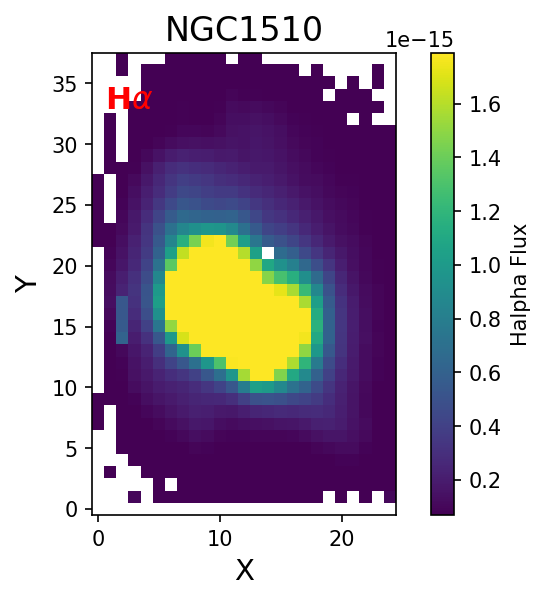

In [9]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

vmin, vmax = np.nanpercentile(Ha_flux_plot, (30, 90))

im = ax.imshow(Ha_flux_plot, origin='lower', vmin=vmin, vmax=vmax)
plt.colorbar(im, ax=ax, label='Halpha Flux')

ax.set_xlabel('X', fontsize=14)
ax.set_ylabel('Y', fontsize=14)
ax.set_title('NGC1510', fontsize=16)
ax.text(0.04, 0.88, r'H$\alpha$', transform=ax.transAxes,
        fontdict={'size': 15, 'color': 'r', 'weight': 'bold'})

plt.show()

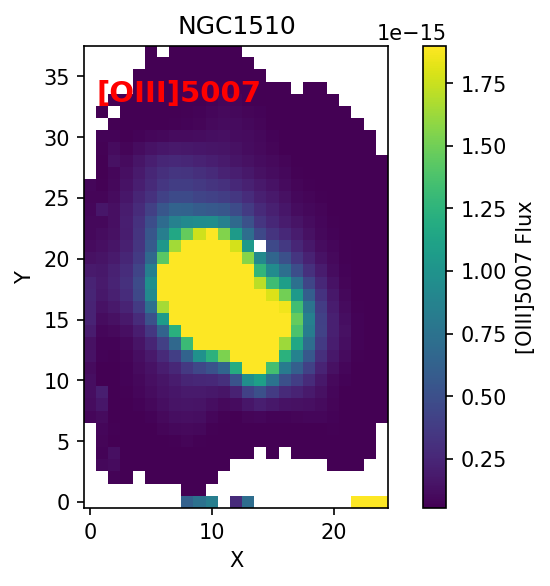

In [10]:
O3_flux = gasflux_dic['[OIII]5007']['flux']
O3_err  = gasflux_dic['[OIII]5007']['flux_err']
O3_snr  = gasflux_dic['[OIII]5007']['flux_snr']

O3_flux_plot = O3_flux.copy()
O3_flux_plot[O3_snr < 7] = np.nan

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
vmin, vmax = np.nanpercentile(O3_flux_plot, (30, 90))
im = ax.imshow(O3_flux_plot, origin='lower', vmin=vmin, vmax=vmax)
plt.colorbar(im, ax=ax, label='[OIII]5007 Flux')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('NGC1510')
ax.text(0.04, 0.88, r'[OIII]5007', transform=ax.transAxes,
        fontdict={'size': 14, 'color': 'r', 'weight': 'bold'})
plt.show()

In [11]:
Ha_flux = data_dic['ppxf_gasflux']['Halpha']['flux'].copy()
Ha_snr  = data_dic['ppxf_gasflux']['Halpha']['flux_snr']

Ha_flux[Ha_snr < 7] = np.nan

center_y, center_x = np.unravel_index(np.nanargmax(Ha_flux), Ha_flux.shape)

print("center_x =", center_x)
print("center_y =", center_y)

center_x = 10
center_y = 18


In [12]:
def plot_line_flux(data_dic, line_name, snr_cut=7, vpercent=(30, 90),
                   figsize=(6, 4), dpi=150, save=False, outname=None):
    gasflux_dic = data_dic['ppxf_gasflux']

    flux = gasflux_dic[line_name]['flux'].copy()
    flux_snr = gasflux_dic[line_name]['flux_snr']

    flux[flux_snr < snr_cut] = np.nan

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    vmin, vmax = np.nanpercentile(flux, vpercent)
    im = ax.imshow(flux, origin='lower', vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, label=f'{line_name} Flux')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('NGC1510')
    ax.text(0.04, 0.88, line_name, transform=ax.transAxes,
            fontdict={'size': 15, 'color': 'r', 'weight': 'bold'})

    plt.tight_layout()

    if save and outname is not None:
        plt.savefig(outname, bbox_inches='tight')

    plt.show()

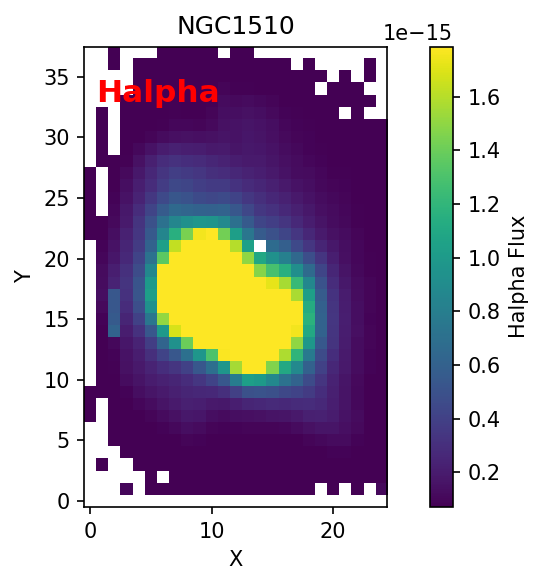

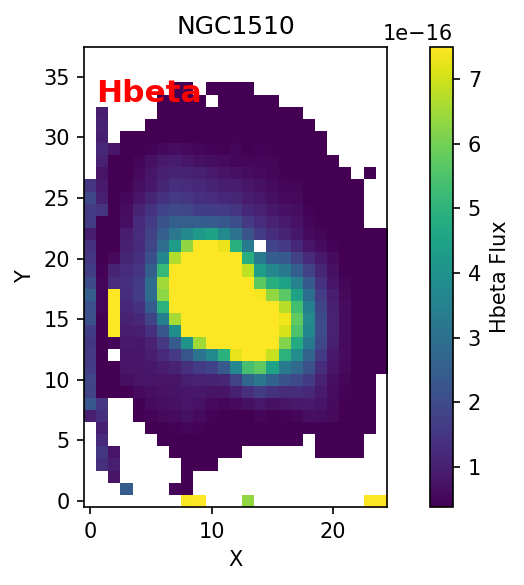

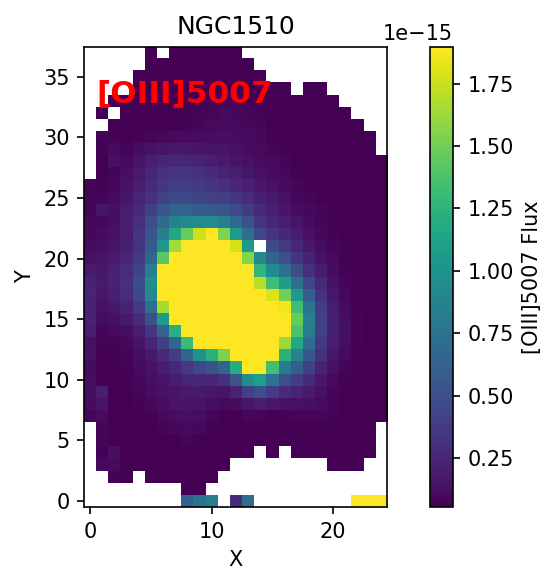

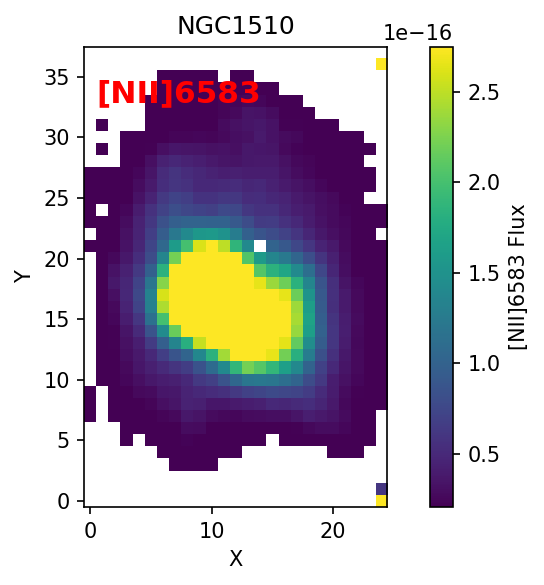

In [13]:
plot_line_flux(data_dic, 'Halpha', save=True, outname='NGC1510_Halpha_map.png')
plot_line_flux(data_dic, 'Hbeta', save=True, outname='NGC1510_Hbeta_map.png')
plot_line_flux(data_dic, '[OIII]5007', save=True, outname='NGC1510_OIII5007_map.png')
plot_line_flux(data_dic, '[NII]6583', save=True, outname='NGC1510_NII6583_map.png')

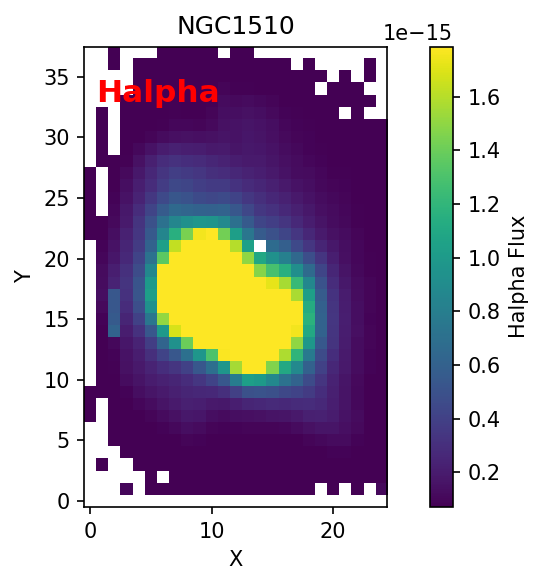

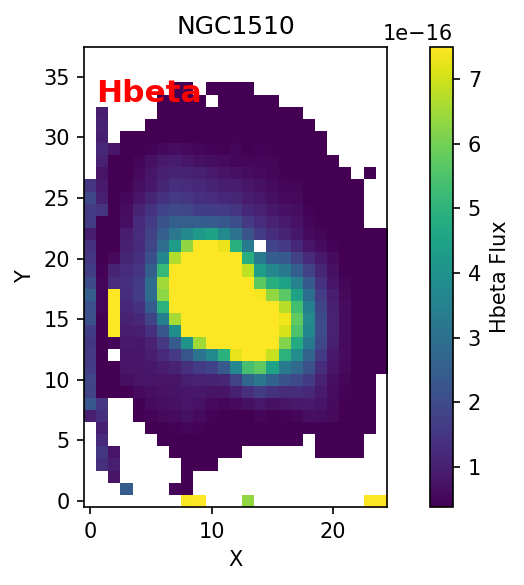

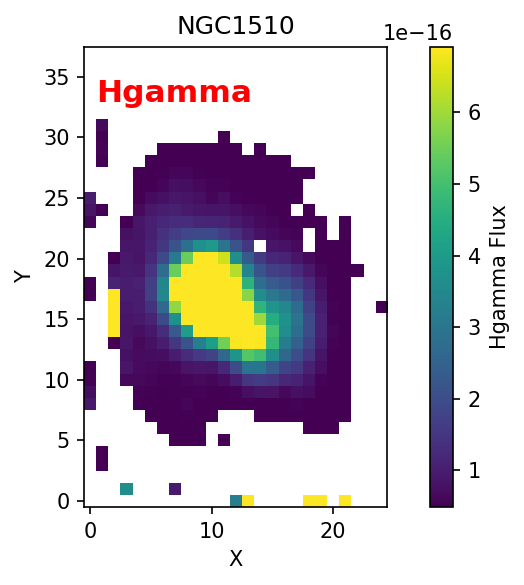

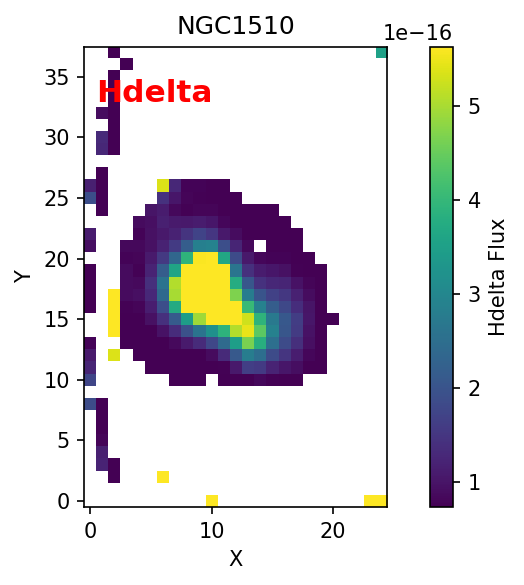

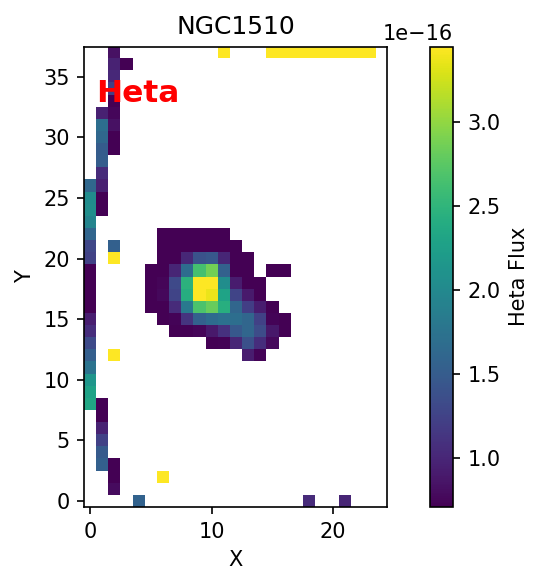

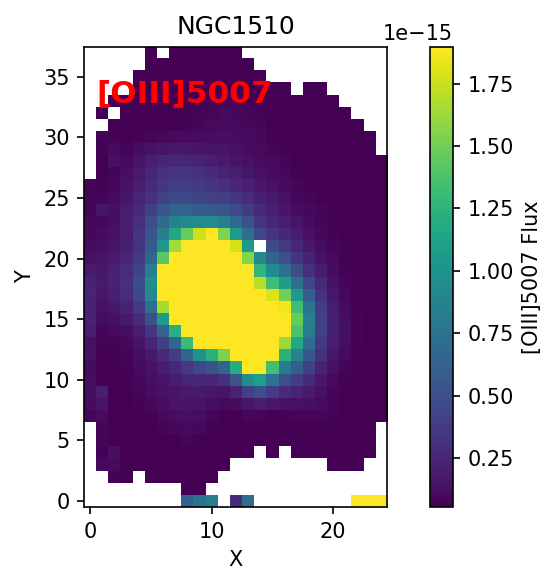

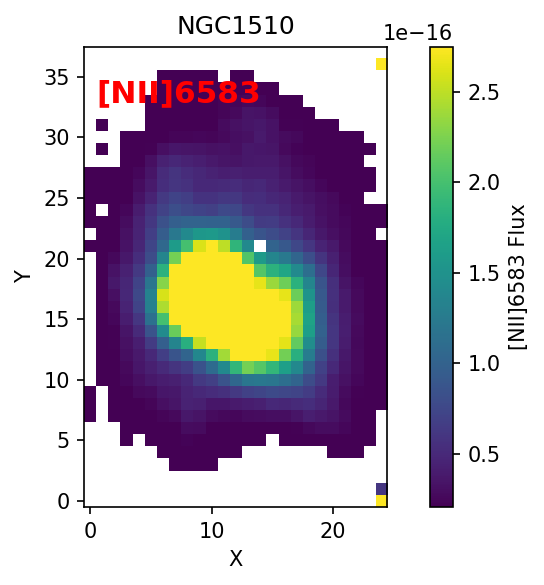

In [14]:
plot_line_flux(data_dic, 'Halpha', save=True, outname='NGC1510_Halpha_map.png')
plot_line_flux(data_dic, 'Hbeta', save=True, outname='NGC1510_Hbeta_map.png')
plot_line_flux(data_dic, 'Hgamma', save=True, outname='NGC1510_Hgamma_map.png')
plot_line_flux(data_dic, 'Hdelta', save=True, outname='NGC1510_Hdelta_map.png')
plot_line_flux(data_dic, 'Heta', save=True, outname='NGC1510_Heta_map.png')
plot_line_flux(data_dic, '[OIII]5007', save=True, outname='NGC1510_OIII5007_map.png')
plot_line_flux(data_dic, '[NII]6583', save=True, outname='NGC1510_NII6583_map.png')

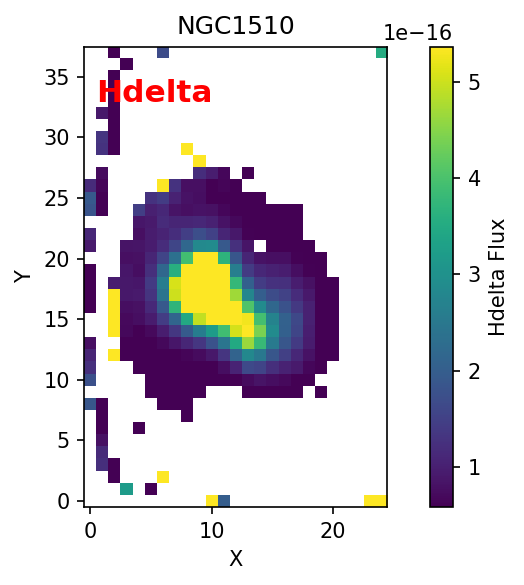

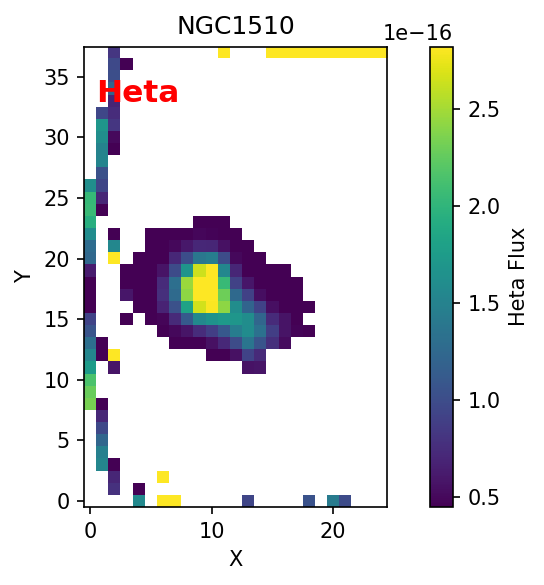

In [15]:
plot_line_flux(data_dic, 'Hdelta', snr_cut=5, save=True, outname='NGC1510_Hdelta_map_snr5.png')
plot_line_flux(data_dic, 'Heta', snr_cut=5, save=True, outname='NGC1510_Heta_map_snr5.png')

In [16]:
def plot_spaxel_spectrum(data_dic, x, y, ylim=(0, 1e-15), save=False, outname=None):
    wave_i = data_dic['wave_fit'][y][x]
    spec_i = data_dic['spec_fit'][y][x]
    contim_spec_i = data_dic['contim_spec'][y][x]
    gas_spec_i = data_dic['ppxf_gas_fit'][y][x]

    fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
    ax.plot(wave_i, spec_i, color='k', label='Observed spectrum')
    ax.plot(wave_i, contim_spec_i + gas_spec_i, color='b', label='Total fit')
    ax.plot(wave_i, contim_spec_i, color='orange', label='Continuum fit')

    ax.tick_params(labelsize=13)
    ax.set_xlabel('Wavelength [obs frame]', fontsize=15)
    ax.set_ylabel(r'Flux density [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]', fontsize=15)
    ax.set_title('NGC1510', fontsize=15)
    ax.text(0.77, 0.88, f'[x,y]=[{x},{y}]',
            transform=ax.transAxes,
            fontdict={'size': 15, 'color': 'r', 'weight': 'bold'})
    ax.set_ylim(*ylim)
    ax.legend(fontsize=11)
    plt.tight_layout()

    if save and outname is not None:
        plt.savefig(outname, bbox_inches='tight')

    plt.show()

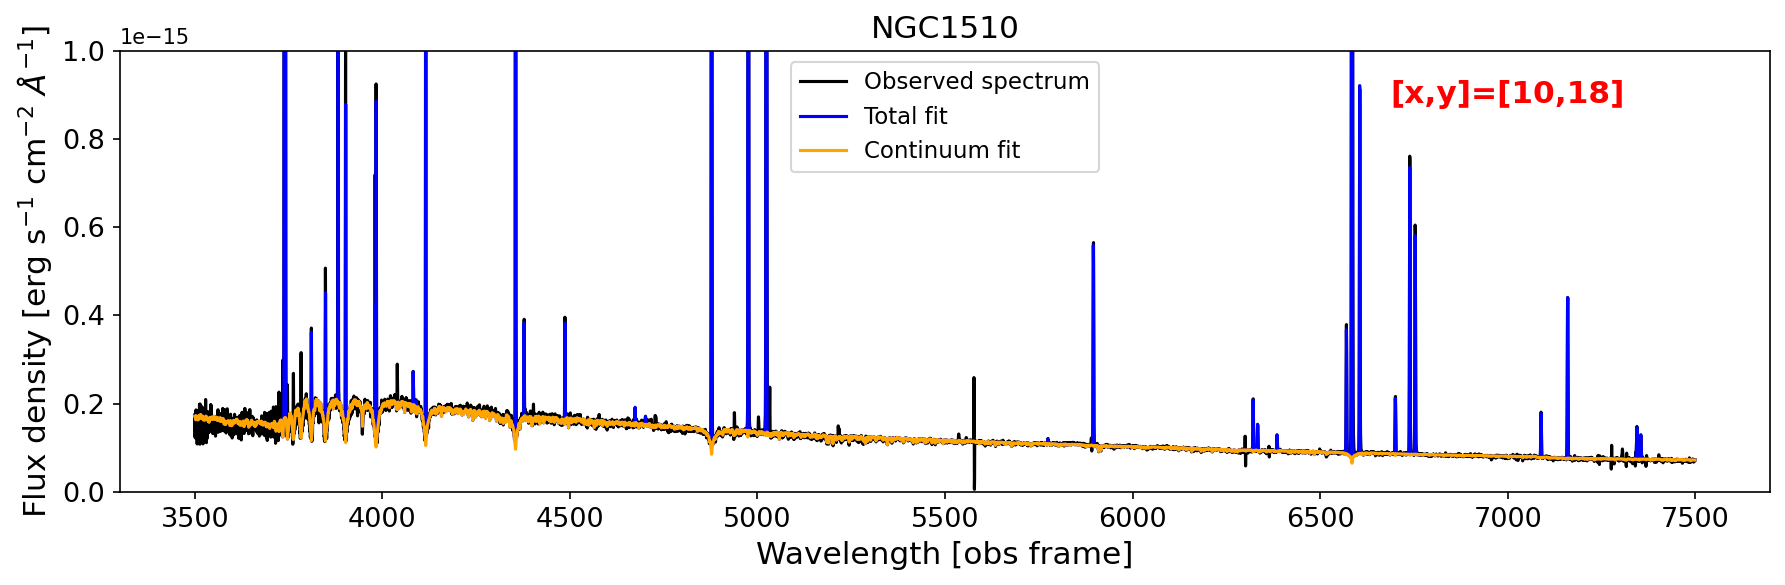

In [17]:
plot_spaxel_spectrum(
    data_dic,
    x=center_x,
    y=center_y,
    save=True,
    outname=f'NGC1510_center_pixel_spectrum_x{center_x}_y{center_y}.png'
)

In [18]:
def plot_line_ratio(data_dic, num_line, den_line, snr_cut=7, figsize=(6, 4), dpi=150):
    gasflux_dic = data_dic['ppxf_gasflux']

    num_flux = gasflux_dic[num_line]['flux'].copy()
    den_flux = gasflux_dic[den_line]['flux'].copy()

    num_snr = gasflux_dic[num_line]['flux_snr']
    den_snr = gasflux_dic[den_line]['flux_snr']

    mask = (num_snr < snr_cut) | (den_snr < snr_cut) | (num_flux <= 0) | (den_flux <= 0)

    ratio = np.full_like(num_flux, np.nan, dtype=float)
    valid = ~mask
    ratio[valid] = num_flux[valid] / den_flux[valid]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    im = ax.imshow(np.log10(ratio), origin='lower')
    plt.colorbar(im, ax=ax, label=f'log10({num_line}/{den_line})')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('NGC1510')
    ax.text(0.04, 0.88, f'log({num_line}/{den_line})', transform=ax.transAxes,
            fontdict={'size': 14, 'color': 'r', 'weight': 'bold'})

    plt.show()

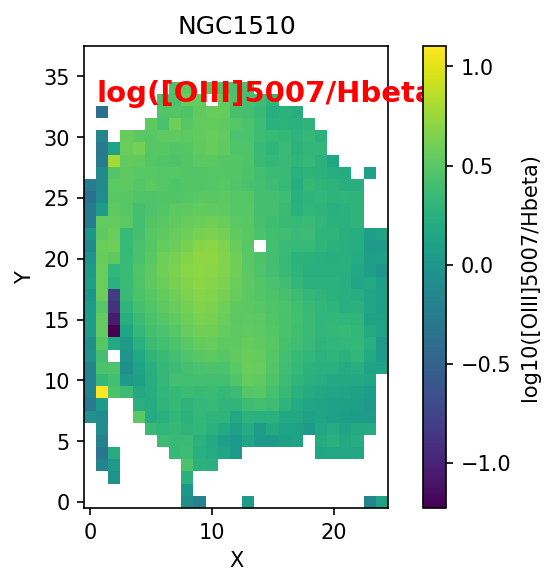

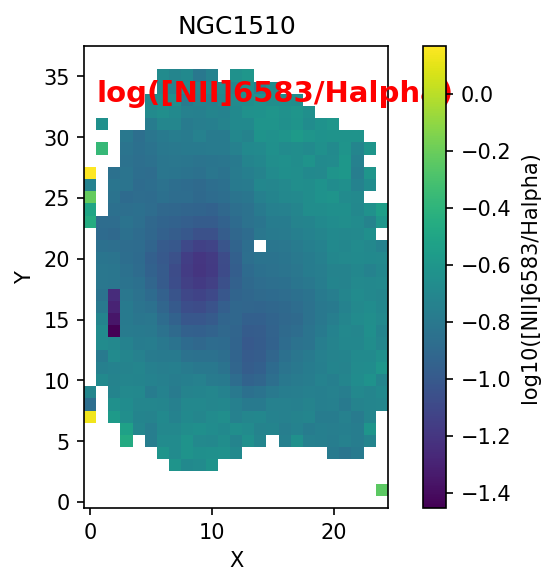

In [19]:
plot_line_ratio(data_dic, '[OIII]5007', 'Hbeta')
plot_line_ratio(data_dic, '[NII]6583', 'Halpha')

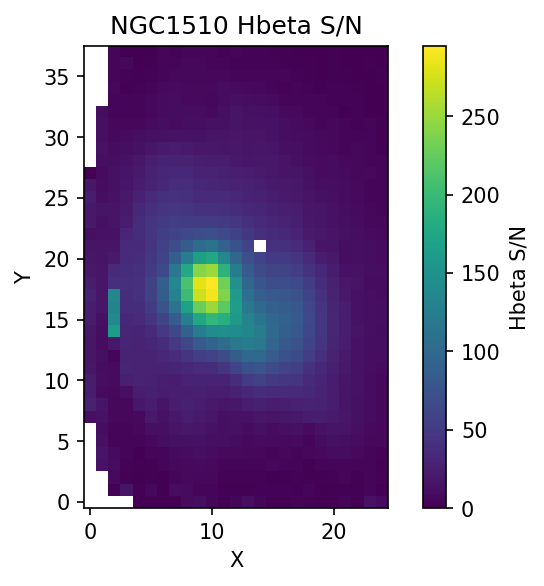

In [20]:
Hb_snr = data_dic['ppxf_gasflux']['Hbeta']['flux_snr']

plt.figure(figsize=(6, 4), dpi=150)
im = plt.imshow(Hb_snr, origin='lower')
plt.colorbar(im, label='Hbeta S/N')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('NGC1510 Hbeta S/N')
plt.show()

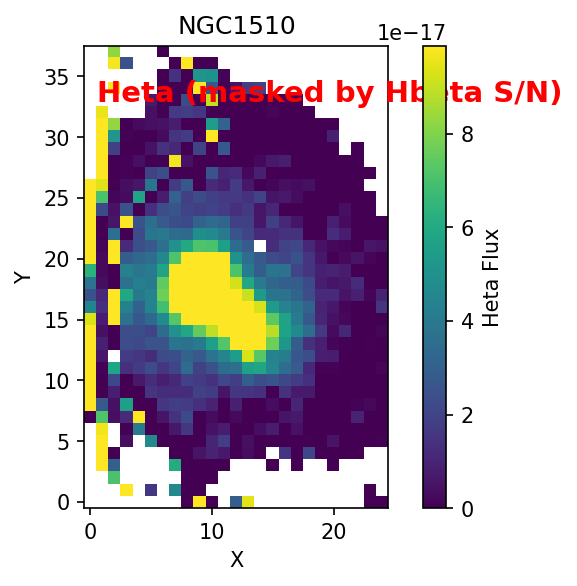

In [21]:
Heta_flux = data_dic['ppxf_gasflux']['Heta']['flux'].copy()
Hb_snr = data_dic['ppxf_gasflux']['Hbeta']['flux_snr']

Heta_flux[Hb_snr < 5] = np.nan

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
vmin, vmax = np.nanpercentile(Heta_flux, (30, 90))
im = ax.imshow(Heta_flux, origin='lower', vmin=vmin, vmax=vmax)
plt.colorbar(im, ax=ax, label='Heta Flux')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('NGC1510')
ax.text(0.04, 0.88, 'Heta (masked by Hbeta S/N)', transform=ax.transAxes,
        fontdict={'size': 14, 'color': 'r', 'weight': 'bold'})
plt.show()

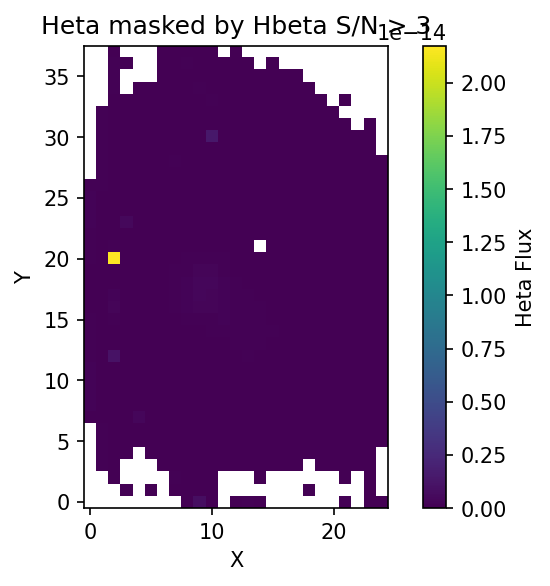

In [22]:
Heta_flux = data_dic['ppxf_gasflux']['Heta']['flux'].copy()
Hb_snr = data_dic['ppxf_gasflux']['Hbeta']['flux_snr']

Heta_flux[Hb_snr < 3] = np.nan

plt.figure(figsize=(6, 4), dpi=150)
im = plt.imshow(Heta_flux, origin='lower')
plt.colorbar(im, label='Heta Flux')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Heta masked by Hbeta S/N > 3')
plt.show()

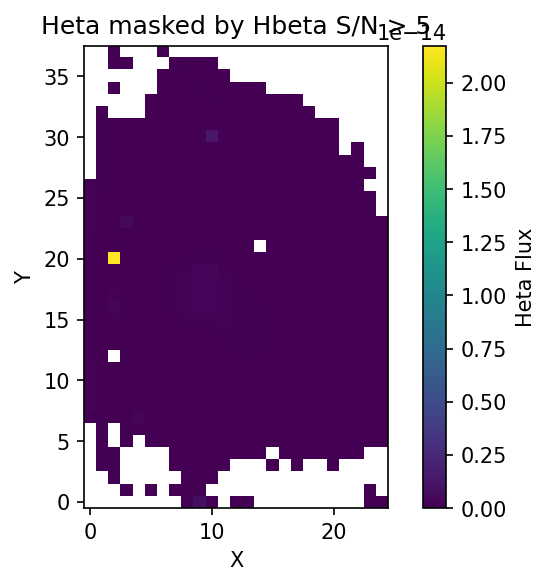

In [23]:
Heta_flux = data_dic['ppxf_gasflux']['Heta']['flux'].copy()
Hb_snr = data_dic['ppxf_gasflux']['Hbeta']['flux_snr']

Heta_flux[Hb_snr < 5] = np.nan

plt.figure(figsize=(6, 4), dpi=150)
im = plt.imshow(Heta_flux, origin='lower')
plt.colorbar(im, label='Heta Flux')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Heta masked by Hbeta S/N > 5')
plt.show()

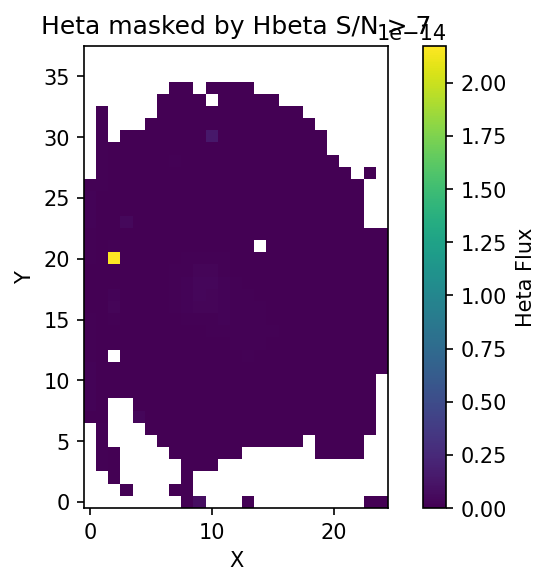

In [24]:
Heta_flux = data_dic['ppxf_gasflux']['Heta']['flux'].copy()
Hb_snr = data_dic['ppxf_gasflux']['Hbeta']['flux_snr']

Heta_flux[Hb_snr < 7] = np.nan

plt.figure(figsize=(6, 4), dpi=150)
im = plt.imshow(Heta_flux, origin='lower')
plt.colorbar(im, label='Heta Flux')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Heta masked by Hbeta S/N > 7')
plt.show()

In [26]:
print("reference_redshift =", data_dic['reference_redshift'])

reference_redshift = 0.0033740948599748338


In [28]:
print(type(full_wave))
print(type(full_wave[0]))
print(type(full_wave[0][0]))

print(type(full_spec))
print(type(full_spec[0]))
print(type(full_spec[0][0]))

print(type(full_var))
print(type(full_var[0]))
print(type(full_var[0][0]))

print("len(full_wave) =", len(full_wave))
print("len(full_wave[0]) =", len(full_wave[0]))
print("len(full_wave[0][0]) =", len(full_wave[0][0]))

<class 'list'>
<class 'list'>
<class 'numpy.ndarray'>
<class 'list'>
<class 'list'>
<class 'numpy.ndarray'>
<class 'list'>
<class 'list'>
<class 'numpy.ndarray'>
len(full_wave) = 38
len(full_wave[0]) = 25
len(full_wave[0][0]) = 13223


z_sys = 0.0033740948599748338
进入初始样本的 spaxel 数 = 839
common_wave length = 10963
wave range = 3488.2303798050957 8969.230379805096
进入最终 composite 的 spaxel 数 = 839
spec_norm_arr shape = (839, 10963)
err_norm_arr shape  = (839, 10963)


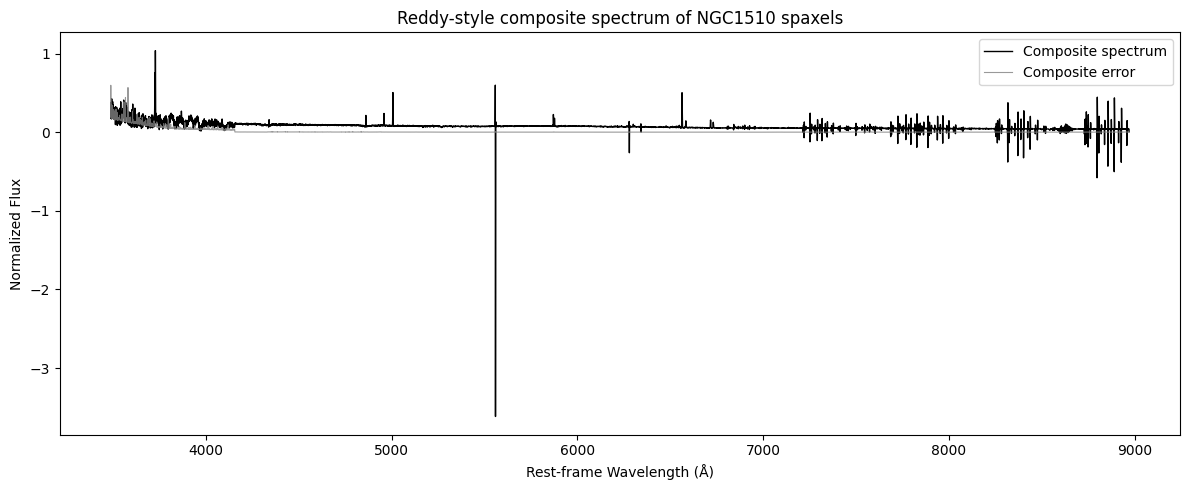

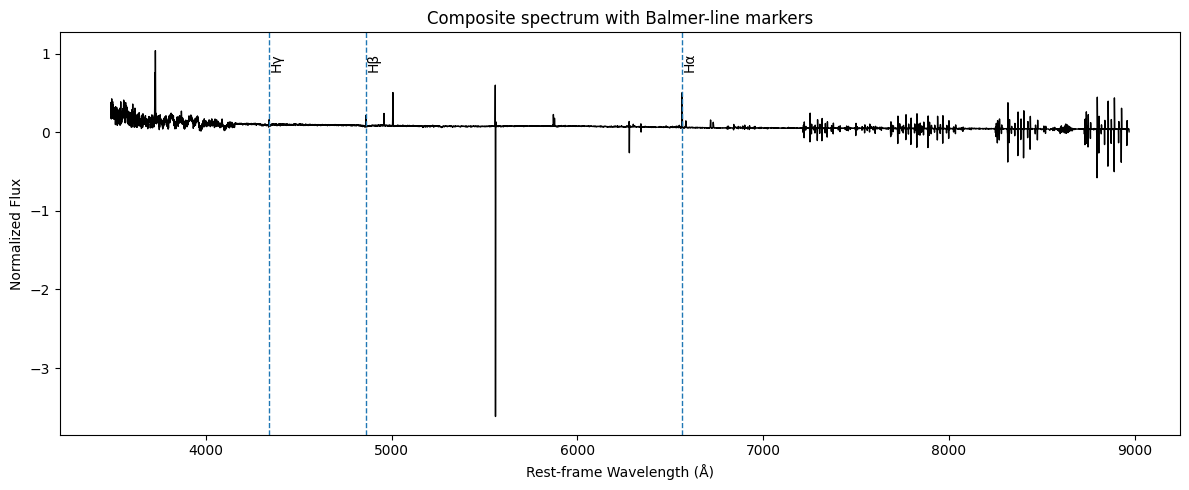

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import os

# =========================
# 1. 读取核心数据
# =========================
full_wave = data_dic['full_wave']
full_spec = data_dic['full_spec']
full_var  = data_dic['full_spec_var']

Ha_flux = data_dic['ppxf_gasflux']['Halpha']['flux']
Ha_snr  = data_dic['ppxf_gasflux']['Halpha']['flux_snr']

z_sys = data_dic['reference_redshift']
print("z_sys =", z_sys)

# =========================
# 2. 按论文思路选样本：
#    只要求 Hα 可用于归一化
# =========================
sample_mask = np.isfinite(Ha_flux) & np.isfinite(Ha_snr) & (Ha_flux > 0) & (Ha_snr >= 3)

ys, xs = np.where(sample_mask)
print("进入初始样本的 spaxel 数 =", len(xs))

# =========================
# 3. 构造公共静止系波长网格（0.5 Å）
#    注意：full_wave 是嵌套 list，要用 [y][x]
# =========================
wave_ref = np.array(full_wave[ys[0]][xs[0]], dtype=float) / (1 + z_sys)

wmin = np.nanmin(wave_ref)
wmax = np.nanmax(wave_ref)
common_wave = np.arange(wmin, wmax, 0.5)

print("common_wave length =", len(common_wave))
print("wave range =", common_wave[0], common_wave[-1])

# =========================
# 4. 每个 spaxel：
#    rest frame -> interp -> Hα normalize
# =========================
spec_norm_list = []
err_norm_list  = []
used_xy = []

for y, x in zip(ys, xs):
    wave_obs = np.array(full_wave[y][x], dtype=float)
    spec_obs = np.array(full_spec[y][x], dtype=float)
    var_obs  = np.array(full_var[y][x], dtype=float)

    wave_rest = wave_obs / (1 + z_sys)
    err_obs = np.sqrt(np.abs(var_obs))

    good = np.isfinite(wave_rest) & np.isfinite(spec_obs) & np.isfinite(err_obs)
    if np.sum(good) < 50:
        continue

    wave_rest = wave_rest[good]
    spec_obs  = spec_obs[good]
    err_obs   = err_obs[good]

    # 插值到统一 0.5 Å 网格
    spec_interp = np.interp(common_wave, wave_rest, spec_obs, left=np.nan, right=np.nan)
    err_interp  = np.interp(common_wave, wave_rest, err_obs,  left=np.nan, right=np.nan)

    # 按 Hα flux 归一化
    ha = Ha_flux[y, x]
    if not np.isfinite(ha) or ha <= 0:
        continue

    spec_norm = spec_interp / ha
    err_norm  = err_interp / ha

    spec_norm_list.append(spec_norm)
    err_norm_list.append(err_norm)
    used_xy.append((x, y))

spec_norm_arr = np.array(spec_norm_list)
err_norm_arr  = np.array(err_norm_list)

print("进入最终 composite 的 spaxel 数 =", spec_norm_arr.shape[0])
print("spec_norm_arr shape =", spec_norm_arr.shape)
print("err_norm_arr shape  =", err_norm_arr.shape)

# =========================
# 5. 3σ rejection + unweighted mean
# =========================
def sigma_clip_mean(arr, nsig=3.0):
    out = np.full(arr.shape[1], np.nan)
    n_used = np.zeros(arr.shape[1], dtype=int)

    for j in range(arr.shape[1]):
        col = arr[:, j]
        col = col[np.isfinite(col)]
        if len(col) == 0:
            continue

        med = np.median(col)
        std = np.std(col)

        if (not np.isfinite(std)) or (std == 0):
            clipped = col
        else:
            clipped = col[np.abs(col - med) <= nsig * std]

        if len(clipped) == 0:
            continue

        out[j] = np.mean(clipped)
        n_used[j] = len(clipped)

    return out, n_used

composite_spec, n_used = sigma_clip_mean(spec_norm_arr, nsig=3.0)

# =========================
# 6. composite error spectrum
# =========================
composite_err = np.full(err_norm_arr.shape[1], np.nan)

for j in range(err_norm_arr.shape[1]):
    col = err_norm_arr[:, j]
    col = col[np.isfinite(col)]
    if len(col) == 0:
        continue
    composite_err[j] = np.sqrt(np.sum(col**2)) / len(col)

# =========================
# 7. 画 composite spectrum
# =========================
plt.figure(figsize=(12,5))
plt.plot(common_wave, composite_spec, color='black', lw=1, label='Composite spectrum')
plt.plot(common_wave, composite_err, color='gray', lw=0.8, alpha=0.8, label='Composite error')

plt.xlabel('Rest-frame Wavelength (Å)')
plt.ylabel('Normalized Flux')
plt.title('Reddy-style composite spectrum of NGC1510 spaxels')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 8. 标出 Hγ / Hβ / Hα
#    用论文表1真空静止波长
# =========================
lines = {
    'Hγ': 4341.69,
    'Hβ': 4862.71,
    'Hα': 6564.60
}

plt.figure(figsize=(12,5))
plt.plot(common_wave, composite_spec, color='black', lw=1)

ymax = np.nanmax(composite_spec)
for name, lam in lines.items():
    plt.axvline(lam, ls='--', lw=1)
    plt.text(lam + 4, 0.78 * ymax, name, rotation=90)

plt.xlabel('Rest-frame Wavelength (Å)')
plt.ylabel('Normalized Flux')
plt.title('Composite spectrum with Balmer-line markers')
plt.tight_layout()
plt.show()

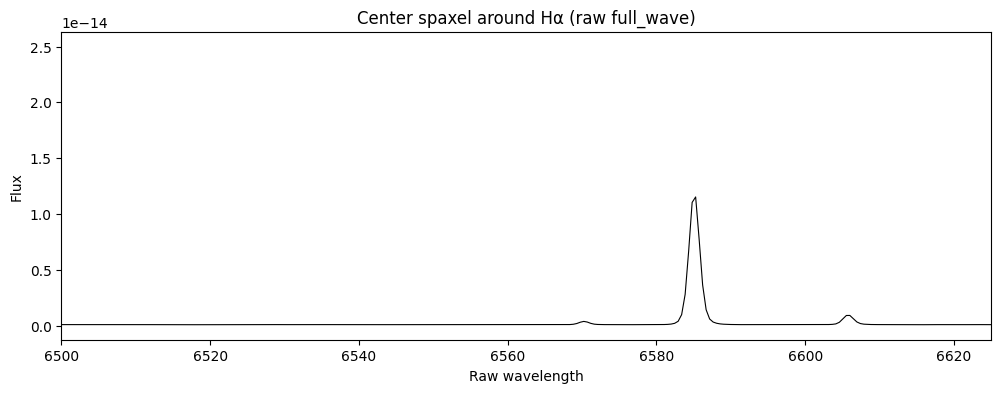

In [30]:
center_x, center_y = 10, 18

wave_raw = np.array(data_dic['full_wave'][center_y][center_x], dtype=float)
spec_raw = np.array(data_dic['full_spec'][center_y][center_x], dtype=float)

plt.figure(figsize=(12,4))
plt.plot(wave_raw, spec_raw, lw=0.8, color='black')
plt.xlim(6500, 6625)
plt.xlabel("Raw wavelength")
plt.ylabel("Flux")
plt.title("Center spaxel around Hα (raw full_wave)")
plt.show()

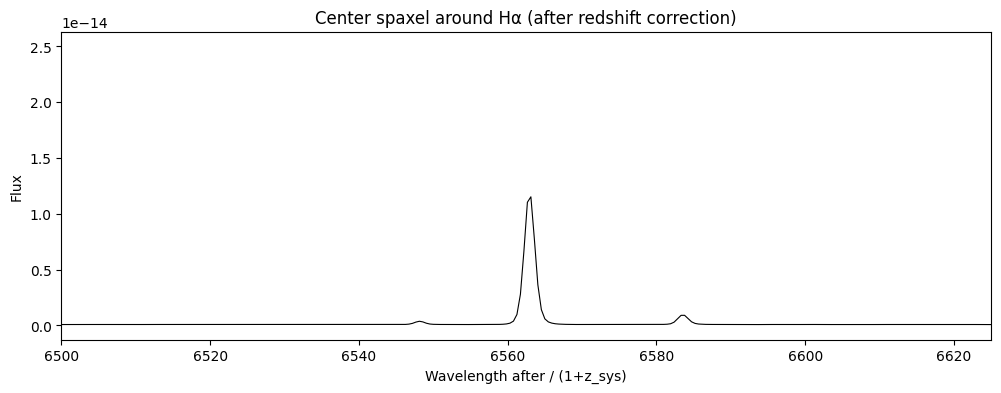

In [31]:
z_sys = data_dic['reference_redshift']

wave_rest_test = wave_raw / (1 + z_sys)

plt.figure(figsize=(12,4))
plt.plot(wave_rest_test, spec_raw, lw=0.8, color='black')
plt.xlim(6500, 6625)
plt.xlabel("Wavelength after / (1+z_sys)")
plt.ylabel("Flux")
plt.title("Center spaxel around Hα (after redshift correction)")
plt.show()

z_sys = 0.0033740948599748338
共同可靠 spaxel 数 = 512


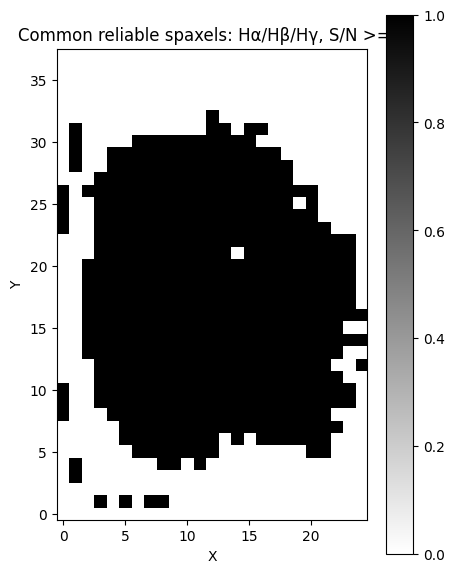

common_wave length = 10963
wave range = 3488.2303798050957 8969.230379805096
进入最终 composite 的 spaxel 数 = 512


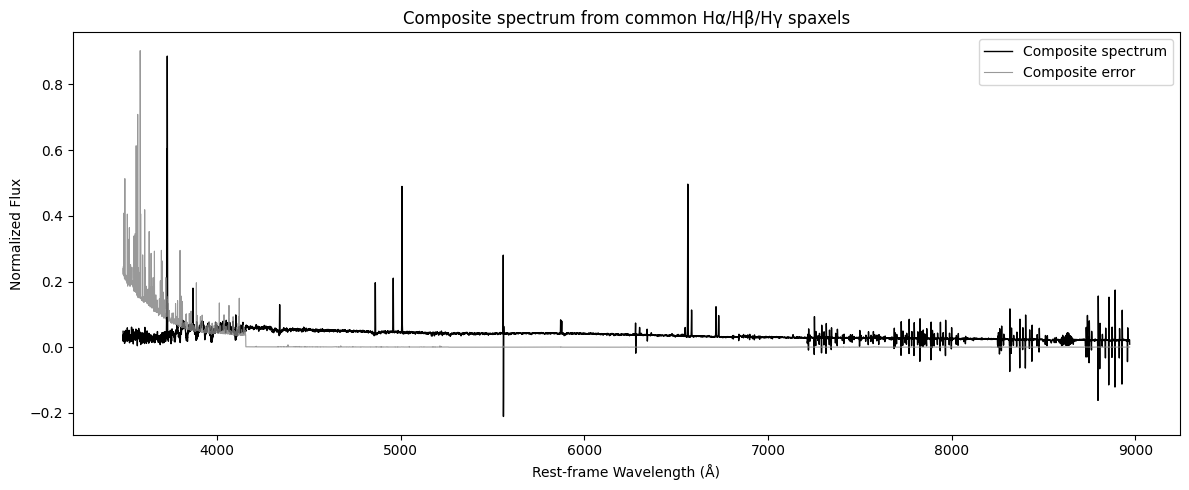

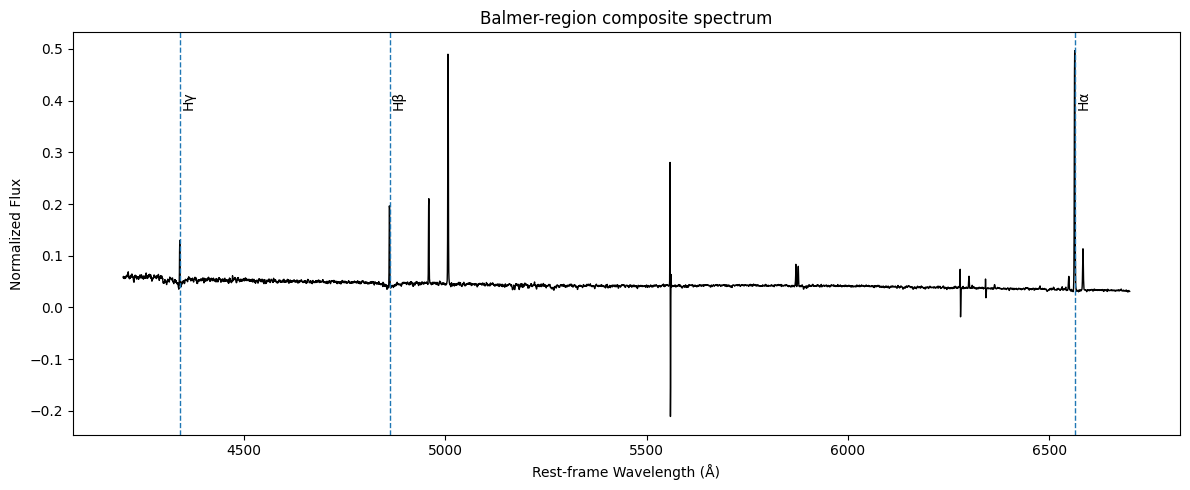

In [32]:
import numpy as np
import matplotlib.pyplot as plt

full_wave = data_dic['full_wave']
full_spec = data_dic['full_spec']
full_var  = data_dic['full_spec_var']

Ha_flux = data_dic['ppxf_gasflux']['Halpha']['flux']
Ha_snr  = data_dic['ppxf_gasflux']['Halpha']['flux_snr']

Hb_flux = data_dic['ppxf_gasflux']['Hbeta']['flux']
Hb_snr  = data_dic['ppxf_gasflux']['Hbeta']['flux_snr']

Hg_flux = data_dic['ppxf_gasflux']['Hgamma']['flux']
Hg_snr  = data_dic['ppxf_gasflux']['Hgamma']['flux_snr']

z_sys = data_dic['reference_redshift']
print("z_sys =", z_sys)

# =========================
# 1. 用 Hα/Hβ/Hγ 共同可靠像素
#    先用 S/N >= 5，若太少再降到 3
# =========================
snr_cut = 5

common_mask = (
    np.isfinite(Ha_flux) & np.isfinite(Ha_snr) & (Ha_flux > 0) & (Ha_snr >= snr_cut) &
    np.isfinite(Hb_flux) & np.isfinite(Hb_snr) & (Hb_flux > 0) & (Hb_snr >= snr_cut) &
    np.isfinite(Hg_flux) & np.isfinite(Hg_snr) & (Hg_flux > 0) & (Hg_snr >= snr_cut)
)

ys, xs = np.where(common_mask)
print("共同可靠 spaxel 数 =", len(xs))

# 看一下共同像素分布
plt.figure(figsize=(5,7))
plt.imshow(common_mask, origin='lower', cmap='gray_r')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Common reliable spaxels: Hα/Hβ/Hγ, S/N >= {snr_cut}')
plt.colorbar()
plt.show()

# =========================
# 2. 公共静止系波长网格（0.5 Å）
# =========================
wave_ref = np.array(full_wave[ys[0]][xs[0]], dtype=float) / (1 + z_sys)
common_wave = np.arange(np.nanmin(wave_ref), np.nanmax(wave_ref), 0.5)

print("common_wave length =", len(common_wave))
print("wave range =", common_wave[0], common_wave[-1])

# =========================
# 3. rest frame -> interp -> Hα normalize
# =========================
spec_norm_list = []
err_norm_list  = []
used_xy = []

for y, x in zip(ys, xs):
    wave_obs = np.array(full_wave[y][x], dtype=float)
    spec_obs = np.array(full_spec[y][x], dtype=float)
    var_obs  = np.array(full_var[y][x], dtype=float)

    wave_rest = wave_obs / (1 + z_sys)
    err_obs = np.sqrt(np.abs(var_obs))

    good = np.isfinite(wave_rest) & np.isfinite(spec_obs) & np.isfinite(err_obs)
    if np.sum(good) < 50:
        continue

    wave_rest = wave_rest[good]
    spec_obs  = spec_obs[good]
    err_obs   = err_obs[good]

    spec_interp = np.interp(common_wave, wave_rest, spec_obs, left=np.nan, right=np.nan)
    err_interp  = np.interp(common_wave, wave_rest, err_obs,  left=np.nan, right=np.nan)

    ha = Ha_flux[y, x]
    spec_norm = spec_interp / ha
    err_norm  = err_interp / ha

    spec_norm_list.append(spec_norm)
    err_norm_list.append(err_norm)
    used_xy.append((x, y))

spec_norm_arr = np.array(spec_norm_list)
err_norm_arr  = np.array(err_norm_list)

print("进入最终 composite 的 spaxel 数 =", spec_norm_arr.shape[0])

# =========================
# 4. 用 MAD 做更稳健的 3σ rejection
# =========================
def sigma_clip_mean(arr, nsig=3.0):
    out = np.full(arr.shape[1], np.nan)
    n_used = np.zeros(arr.shape[1], dtype=int)

    for j in range(arr.shape[1]):
        col = arr[:, j]
        col = col[np.isfinite(col)]
        if len(col) == 0:
            continue

        med = np.median(col)
        mad = np.median(np.abs(col - med))

        if (not np.isfinite(mad)) or (mad == 0):
            clipped = col
        else:
            sigma = 1.4826 * mad
            clipped = col[np.abs(col - med) <= nsig * sigma]

        if len(clipped) == 0:
            continue

        out[j] = np.mean(clipped)
        n_used[j] = len(clipped)

    return out, n_used

composite_spec, n_used = sigma_clip_mean(spec_norm_arr, nsig=3.0)

# =========================
# 5. composite error
# =========================
composite_err = np.full(err_norm_arr.shape[1], np.nan)
for j in range(err_norm_arr.shape[1]):
    col = err_norm_arr[:, j]
    col = col[np.isfinite(col)]
    if len(col) == 0:
        continue
    composite_err[j] = np.sqrt(np.sum(col**2)) / len(col)

# 参与样本太少的波长点直接去掉
composite_spec[n_used < 10] = np.nan
composite_err[n_used < 10] = np.nan

# =========================
# 6. 画总 composite
# =========================
plt.figure(figsize=(12,5))
plt.plot(common_wave, composite_spec, color='black', lw=1, label='Composite spectrum')
plt.plot(common_wave, composite_err, color='gray', lw=0.8, alpha=0.8, label='Composite error')
plt.xlabel('Rest-frame Wavelength (Å)')
plt.ylabel('Normalized Flux')
plt.title('Composite spectrum from common Hα/Hβ/Hγ spaxels')
plt.legend()
plt.tight_layout()
plt.show()

# 只看 Balmer 区域
lines = {'Hγ': 4341.69, 'Hβ': 4862.71, 'Hα': 6564.60}

plt.figure(figsize=(12,5))
m = (common_wave >= 4200) & (common_wave <= 6700)
plt.plot(common_wave[m], composite_spec[m], color='black', lw=1)

ymax = np.nanmax(composite_spec[m])
for name, lam in lines.items():
    plt.axvline(lam, ls='--', lw=1)
    plt.text(lam + 4, 0.78 * ymax, name, rotation=90)

plt.xlabel('Rest-frame Wavelength (Å)')
plt.ylabel('Normalized Flux')
plt.title('Balmer-region composite spectrum')
plt.tight_layout()
plt.show()

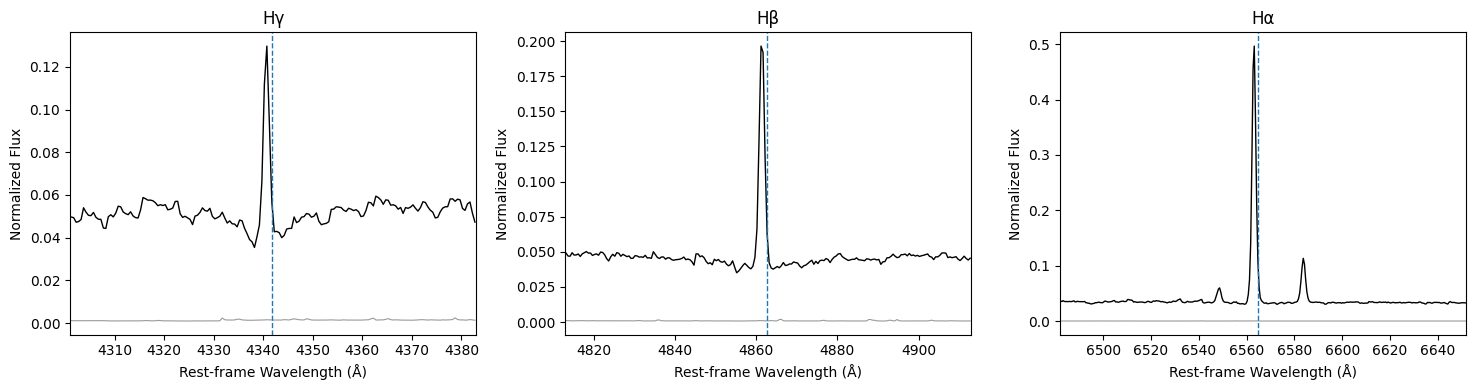

In [33]:
# 论文表1中的静止系真空波长和拟合窗口
balmer_windows = {
    'Hγ': (4341.69, 4301, 4383),
    'Hβ': (4862.71, 4813, 4913),
    'Hα': (6564.60, 6482, 6652),
}

plt.figure(figsize=(15,4))

for i, (name, (lam0, w1, w2)) in enumerate(balmer_windows.items(), start=1):
    plt.subplot(1, 3, i)
    m = (common_wave >= w1) & (common_wave <= w2)
    plt.plot(common_wave[m], composite_spec[m], color='black', lw=1, label='Composite')
    plt.plot(common_wave[m], composite_err[m], color='gray', lw=0.8, alpha=0.8, label='Error')
    plt.axvline(lam0, ls='--', lw=1, color='tab:blue')
    plt.title(name)
    plt.xlabel('Rest-frame Wavelength (Å)')
    plt.ylabel('Normalized Flux')
    plt.xlim(w1, w2)

plt.tight_layout()
plt.show()

In [34]:
import os
outdir = 'common_spaxel_balmer_panels'
os.makedirs(outdir, exist_ok=True)

for k, (x, y) in enumerate(used_xy):
    spec_k = spec_norm_arr[k]

    plt.figure(figsize=(15,4))

    for i, (name, (lam0, w1, w2)) in enumerate(balmer_windows.items(), start=1):
        plt.subplot(1, 3, i)
        m = (common_wave >= w1) & (common_wave <= w2)
        plt.plot(common_wave[m], spec_k[m], color='black', lw=0.8)
        plt.axvline(lam0, ls='--', lw=1, color='tab:blue')
        plt.title(f'{name}  (x={x}, y={y})')
        plt.xlabel('Rest-frame Wavelength (Å)')
        plt.ylabel('Norm Flux')
        plt.xlim(w1, w2)

    plt.tight_layout()
    plt.savefig(f'{outdir}/spaxel_x{x}_y{y}_balmer.png', dpi=150)
    plt.close()

print("已保存到:", outdir)

已保存到: common_spaxel_balmer_panels
